# CIFAR-10 Uncertainty Benchmark — Evaluation

Central analysis notebook for the thesis *Decomposing Uncertainty in Deep Neural
Networks via the Variational Information Bottleneck and Stochastic
Weight Averaging–Gaussian*.

Each model notebook saves a `*_results.npz` file with a shared schema. This
notebook loads all of them and produces a single, comparable analysis of:

1. **Predictive performance** — accuracy (clean / corrupted), NLL, Brier score.
2. **Calibration** — Expected Calibration Error (ECE) and reliability diagrams.
3. **OOD detection** — AUROC / AUPR using predictive entropy, on SVHN (domain
   shift) and CIFAR-10-C (corruption).
4. **Selective prediction** — risk–coverage curves and AURC.
5. **Uncertainty decomposition** — the two-way (aleatoric / epistemic) split for
   every sampling model, and the three-way (weight-epistemic / bottleneck /
   residual) split that is the thesis's central contribution — including a direct
   test of the research question: *do the components respond differently to
   in-distribution ambiguity (CIFAR-10-C) versus out-of-distribution inputs
   (SVHN)?*

The notebook is robust to missing files: any model whose `.npz` is absent is
skipped, and the tables/plots adapt to whichever models are present.

## 0. Configuration

`RESULTS_DIR` is the only thing you normally need to change. Point it at the
folder holding the `*_results.npz` files (e.g. a Google Drive mount in Colab,
or `.` if they sit next to this notebook).

In [1]:
import os, json, warnings
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.metrics import roc_auc_score, average_precision_score, roc_curve

warnings.filterwarnings("ignore", category=RuntimeWarning)

# >>> Mount Google Drive (Colab) and point at the SAME folder your model
# notebooks saved their *_results.npz files to. In those notebooks this was
# RESULTS_DIR = "/content/drive/MyDrive/thesis_results". <<<
try:
    from google.colab import drive
    drive.mount("/content/drive")
    RESULTS_DIR = "/content/drive/MyDrive/thesis_results"
except Exception:
    RESULTS_DIR = "."   # running locally: put the *_results.npz files next to this notebook
FIG_DIR = os.path.join(RESULTS_DIR, "eval_figures")     # saved figures persist to Drive
os.makedirs(FIG_DIR, exist_ok=True)

NUM_CLASSES = 10
ECE_BINS    = 15

# filename -> (display name, plot colour). Order defines plotting/table order.
MODEL_REGISTRY = [
    ("deterministic_results.npz",   "Deterministic",  "#7f7f7f"),
    ("mc_dropout_results.npz",      "MC Dropout",     "#1f77b4"),
    ("swag_results.npz",            "SWAG",           "#2ca02c"),
    ("vib_alone_results.npz",       "VIB",            "#ff7f0e"),
    ("deep_ensemble_5_results.npz", "Deep Ensemble",  "#9467bd"),
    ("vib_swag_results.npz",        "VIB-SWAG",       "#d62728"),
]
DISPLAY  = {f: d for f, d, _ in MODEL_REGISTRY}
COLOR    = {d: c for _, d, c in MODEL_REGISTRY}

plt.rcParams.update({"figure.dpi": 110, "font.size": 10,
                     "axes.grid": True, "grid.alpha": 0.3})

Mounted at /content/drive


## 1. Metric library

All entropies are in **nats** (natural log). The decomposition is additive in
whatever base is used, so the choice only affects absolute scale, not any
comparison or ranking.

The three-way decomposition mirrors §3.4 of the proposal exactly. Given
per-sample probabilities `all_probs` of shape `(S, M, N, C)` (S weight samples,
M bottleneck samples), with $\bar p = \tfrac{1}{SM}\sum_{s,m} p_{s,m}$ and
$\bar p_s = \tfrac{1}{M}\sum_m p_{s,m}$:

- **total** $= H[\bar p]$
- **weight-epistemic** $= H[\bar p] - \tfrac1S\sum_s H[\bar p_s]$
- **bottleneck** $= \tfrac1S\sum_s\big(H[\bar p_s] - \tfrac1M\sum_m H[p_{s,m}]\big)$
- **residual** $= \tfrac{1}{SM}\sum_{s,m} H[p_{s,m}]$

These sum to **total** by construction (a telescoping of conditional entropies),
which the notebook checks numerically.

> **Note for the VIB-SWAG notebook:** that notebook calls `decompose_uncertainty(...)`
> but never defines it. The canonical definition is `decompose_three_way` below —
> paste it (renamed) into the VIB-SWAG notebook before its prediction cell, or it
> will raise a `NameError`.

In [2]:
def entropy(p, axis=-1, eps=1e-12):
    """Shannon entropy in nats along `axis`."""
    p = np.clip(np.asarray(p, dtype=np.float64), eps, 1.0)
    return -np.sum(p * np.log(p), axis=axis)


def decompose_two_way(all_probs):
    """Standard mutual-information split (Depeweg et al. 2018).
    all_probs: (K, N, C). Returns dict of (N,) arrays."""
    all_probs = np.asarray(all_probs)
    mean_p    = all_probs.mean(axis=0)                 # (N, C)
    total     = entropy(mean_p)                         # (N,)
    aleatoric = entropy(all_probs, axis=-1).mean(0)     # E_k H[p_k]
    epistemic = total - aleatoric                       # mutual information
    return {"total": total, "aleatoric": aleatoric, "epistemic": epistemic}


def decompose_three_way(all_probs):
    """Three-way decomposition (proposal §3.4).
    all_probs: (S, M, N, C). Returns dict of (N,) arrays summing to total."""
    ap       = np.asarray(all_probs)
    mean_p   = ap.mean(axis=(0, 1))                     # (N, C)
    mean_p_s = ap.mean(axis=1)                          # (S, N, C)
    H_total  = entropy(mean_p)                          # (N,)
    H_s      = entropy(mean_p_s, axis=-1)               # (S, N)
    H_sm     = entropy(ap, axis=-1)                     # (S, M, N)
    weight_epistemic = H_total - H_s.mean(axis=0)
    bottleneck       = (H_s - H_sm.mean(axis=1)).mean(axis=0)
    residual         = H_sm.mean(axis=(0, 1))
    return {"total": H_total, "weight_epistemic": weight_epistemic,
            "bottleneck": bottleneck, "residual": residual}


def expected_calibration_error(probs, labels, n_bins=ECE_BINS):
    """Equal-width-bin ECE on max-probability confidence. Returns (ece, bins)
    where bins is a list of (bin_centre, accuracy, confidence, count)."""
    probs = np.asarray(probs); labels = np.asarray(labels)
    conf  = probs.max(axis=1)
    pred  = probs.argmax(axis=1)
    correct = (pred == labels).astype(np.float64)
    edges = np.linspace(0.0, 1.0, n_bins + 1)
    idx   = np.clip(np.digitize(conf, edges[1:-1], right=True), 0, n_bins - 1)
    ece, stats = 0.0, []
    N = len(labels)
    for b in range(n_bins):
        m = idx == b
        if m.any():
            acc, c, w = correct[m].mean(), conf[m].mean(), m.sum() / N
            ece += w * abs(acc - c)
            stats.append((0.5 * (edges[b] + edges[b + 1]), acc, c, int(m.sum())))
    return ece, stats


def nll(probs, labels, eps=1e-12):
    probs = np.clip(np.asarray(probs), eps, 1.0)
    return float(-np.log(probs[np.arange(len(labels)), labels]).mean())


def brier(probs, labels, n_classes=NUM_CLASSES):
    onehot = np.eye(n_classes)[np.asarray(labels)]
    return float(((np.asarray(probs) - onehot) ** 2).sum(axis=1).mean())


def accuracy(probs, labels):
    return float((np.asarray(probs).argmax(1) == np.asarray(labels)).mean())


def ood_scores(score_id, score_ood):
    """AUROC / AUPR treating OOD as the positive class (higher score = more OOD)."""
    y = np.concatenate([np.zeros(len(score_id)), np.ones(len(score_ood))])
    s = np.concatenate([score_id, score_ood])
    return {"auroc": float(roc_auc_score(y, s)),
            "aupr":  float(average_precision_score(y, s))}


def risk_coverage(probs, labels):
    """Selective-prediction curve, ordering by confidence (descending).
    Returns coverage, risk (cumulative error), and AURC (lower is better)."""
    probs = np.asarray(probs); labels = np.asarray(labels)
    conf  = probs.max(1)
    err   = (probs.argmax(1) != labels).astype(np.float64)
    order = np.argsort(-conf)
    err_s = err[order]
    n     = len(err)
    coverage = np.arange(1, n + 1) / n
    risk     = np.cumsum(err_s) / np.arange(1, n + 1)
    return coverage, risk, float(risk.mean())

## 2. Load all available result files

Each `.npz` is loaded into a dict. Missing files are skipped with a warning.
We also verify that every model used the same CIFAR-10 test labels (they should,
since the label order is deterministic), so per-input comparisons are valid.

In [3]:
def load_npz(path):
    with np.load(path, allow_pickle=False) as d:
        out = {k: d[k] for k in d.files}
    return out

def scalar(d, key, default=None):
    if key not in d: return default
    v = d[key]
    return v.item() if getattr(v, "ndim", None) == 0 else v

RESULTS = {}   # display name -> dict
for fname, disp, _ in MODEL_REGISTRY:
    path = os.path.join(RESULTS_DIR, fname)
    if not os.path.exists(path):
        print(f"  [skip] {fname} not found")
        continue
    RESULTS[disp] = load_npz(path)

if not RESULTS:
    raise FileNotFoundError(
        f"No *_results.npz files found in '{RESULTS_DIR}'. "
        "Set RESULTS_DIR to the folder containing them.")

MODELS = [d for _, d, _ in MODEL_REGISTRY if d in RESULTS]   # preserve order

# ---- Optional OOD splits --------------------------------------------------
# Not every notebook saves every OOD set. SVHN and CIFAR-10-C are treated as
# OPTIONAL: a column / panel / section only appears if at least one loaded
# model actually carries that split. The short label (e.g. "C-10-C") is what
# the downstream tables and key-findings expect, so keep it stable.
OOD_SPLITS = [("svhn", "SVHN"), ("cifar10c", "C-10-C")]
AVAILABLE_OOD = [(s, lbl) for s, lbl in OOD_SPLITS
                 if any(f"probs_{s}" in RESULTS[m] for m in MODELS)]
print("OOD splits available:", [lbl for _, lbl in AVAILABLE_OOD] or "none")

# Label-consistency check
ref_labels = RESULTS[MODELS[0]]["labels_test"]
for m in MODELS[1:]:
    if not np.array_equal(RESULTS[m]["labels_test"], ref_labels):
        print(f"  [warn] {m} has different test labels than {MODELS[0]} - "
              "per-input comparisons may be invalid.")

# Summary of what loaded (optional columns appear only when present)
rows = []
for m in MODELS:
    r = RESULTS[m]
    ap = r.get("all_probs_test")
    if ap is None:        shape_desc = "(point)"
    elif ap.ndim == 4:    shape_desc = f"(S={ap.shape[0]}, M={ap.shape[1]})"
    elif ap.ndim == 3:    shape_desc = f"(samples={ap.shape[0]})"
    else:                 shape_desc = "(point)"
    row = {"model": m, "N_test": r["probs_test"].shape[0], "samples": shape_desc}
    if "probs_svhn" in r:        row["N_svhn"] = r["probs_svhn"].shape[0]
    if "probs_cifar10c" in r:    row["N_cifar10c"] = r["probs_cifar10c"].shape[0]
    if "cifar10c_severity" in r: row["c10c_severity"] = int(scalar(r, "cifar10c_severity", -1))
    rows.append(row)
print(f"Loaded {len(MODELS)} models:")
display(pd.DataFrame(rows).set_index("model"))


OOD splits available: ['SVHN']
Loaded 6 models:


,N_test,samples,N_svhn
model,,,
Deterministic,10000,(samples=1),26032
MC Dropout,10000,(samples=30),26032
SWAG,10000,(samples=30),26032
VIB,10000,(samples=30),26032
Deep Ensemble,10000,(samples=5),26032
VIB-SWAG,10000,"(S=30, M=10)",26032


## 3. Predictive performance & calibration

Accuracy on clean CIFAR-10 and on CIFAR-10-C (mean over the loaded corruptions
at the saved severity), plus NLL, Brier score, and ECE — all computed on the
**mean** predictive distribution. Lower NLL / Brier / ECE is better.

In [4]:
perf = []
for m in MODELS:
    r = RESULTS[m]
    ece, _ = expected_calibration_error(r["probs_test"], r["labels_test"])
    row = {
        "Model":       m,
        "Acc (clean)": accuracy(r["probs_test"], r["labels_test"]),
        "NLL":         nll(r["probs_test"], r["labels_test"]),
        "Brier":       brier(r["probs_test"], r["labels_test"]),
        "ECE":         ece,
    }
    # CIFAR-10-C accuracy only if the model saved that split
    if "probs_cifar10c" in r and "labels_cifar10c" in r:
        row["Acc (C-10-C)"] = accuracy(r["probs_cifar10c"], r["labels_cifar10c"])
    perf.append(row)
perf_df = pd.DataFrame(perf).set_index("Model")
perf_df.to_csv(os.path.join(FIG_DIR, "performance_table.csv"))
display(perf_df.round(4))


,Acc (clean),NLL,Brier,ECE
Model,,,,
Deterministic,0.9111,0.3406,0.1402,0.0449
MC Dropout,0.9105,0.2752,0.1290,0.0218
SWAG,0.9092,0.3171,0.1382,0.0414
VIB,0.9103,0.3975,0.1452,0.0567
Deep Ensemble,0.9307,0.2091,0.1029,0.0084
VIB-SWAG,0.9109,0.3516,0.1383,0.0504


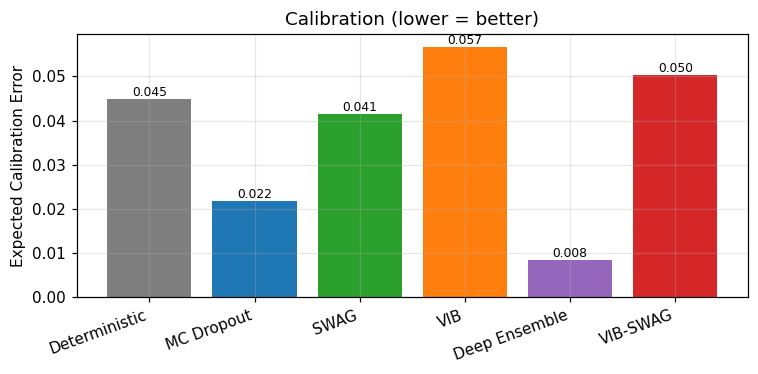

In [5]:
# ECE bar chart
fig, ax = plt.subplots(figsize=(7, 3.5))
vals = perf_df["ECE"].values
ax.bar(range(len(MODELS)), vals, color=[COLOR[m] for m in MODELS])
ax.set_xticks(range(len(MODELS))); ax.set_xticklabels(MODELS, rotation=20, ha="right")
ax.set_ylabel("Expected Calibration Error"); ax.set_title("Calibration (lower = better)")
for i, v in enumerate(vals):
    ax.text(i, v, f"{v:.3f}", ha="center", va="bottom", fontsize=8)
plt.tight_layout(); plt.savefig(os.path.join(FIG_DIR, "ece_bars.png")); plt.show()

### 3b. Reliability diagrams

Bars below the diagonal indicate over-confidence (confidence exceeds accuracy);
bars above indicate under-confidence. The grey diagonal is perfect calibration.

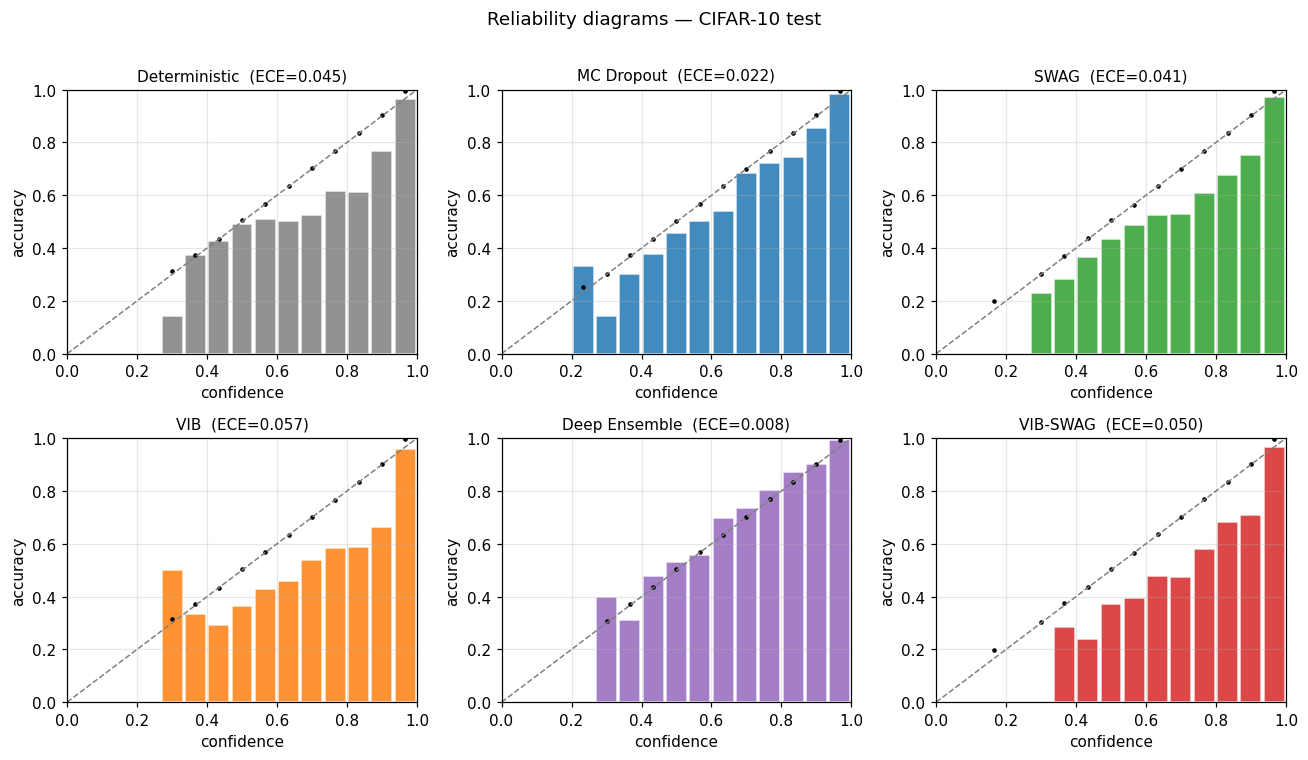

In [6]:
ncol = 3
nrow = int(np.ceil(len(MODELS) / ncol))
fig, axes = plt.subplots(nrow, ncol, figsize=(4 * ncol, 3.4 * nrow), squeeze=False)
for ax in axes.flat: ax.set_visible(False)
for i, m in enumerate(MODELS):
    ax = axes.flat[i]; ax.set_visible(True)
    r = RESULTS[m]
    ece, bins = expected_calibration_error(r["probs_test"], r["labels_test"])
    if bins:
        centres = [b[0] for b in bins]; accs = [b[1] for b in bins]
        widths  = 1.0 / ECE_BINS
        ax.bar(centres, accs, width=widths * 0.9, color=COLOR[m], alpha=0.85,
               edgecolor="white", label="accuracy")
        ax.plot([c for c in centres], [b[2] for b in bins], "k.", ms=4, label="confidence")
    ax.plot([0, 1], [0, 1], color="grey", ls="--", lw=1)
    ax.set_xlim(0, 1); ax.set_ylim(0, 1)
    ax.set_title(f"{m}  (ECE={ece:.3f})", fontsize=10)
    ax.set_xlabel("confidence"); ax.set_ylabel("accuracy")
fig.suptitle("Reliability diagrams — CIFAR-10 test", y=1.01, fontsize=12)
plt.tight_layout(); plt.savefig(os.path.join(FIG_DIR, "reliability.png"), bbox_inches="tight"); plt.show()

## 4. Out-of-distribution detection

The OOD score is the **predictive entropy** of the mean distribution — a
model-agnostic scalar available for every method, so the comparison is fair.
A good uncertainty model assigns higher entropy to OOD inputs, giving AUROC
well above 0.5. SVHN is a full domain shift; CIFAR-10-C is in-distribution
corruption (a milder, different failure mode).

In [7]:
ood_rows = []
for m in MODELS:
    r = RESULTS[m]
    h_id = entropy(r["probs_test"])
    row = {"Model": m}
    for split, lbl in AVAILABLE_OOD:
        if f"probs_{split}" not in r:
            continue
        s = ood_scores(h_id, entropy(r[f"probs_{split}"]))
        row[f"AUROC {lbl}"] = s["auroc"]
        row[f"AUPR {lbl}"]  = s["aupr"]
    ood_rows.append(row)
ood_df = pd.DataFrame(ood_rows).set_index("Model")
ood_df.to_csv(os.path.join(FIG_DIR, "ood_detection_table.csv"))
display(ood_df.round(4))


,AUROC SVHN,AUPR SVHN
Model,,
Deterministic,0.9097,0.9470
MC Dropout,0.9071,0.9523
SWAG,0.9264,0.9566
VIB,0.9161,0.9530
Deep Ensemble,0.9447,0.9675
VIB-SWAG,0.9061,0.9479


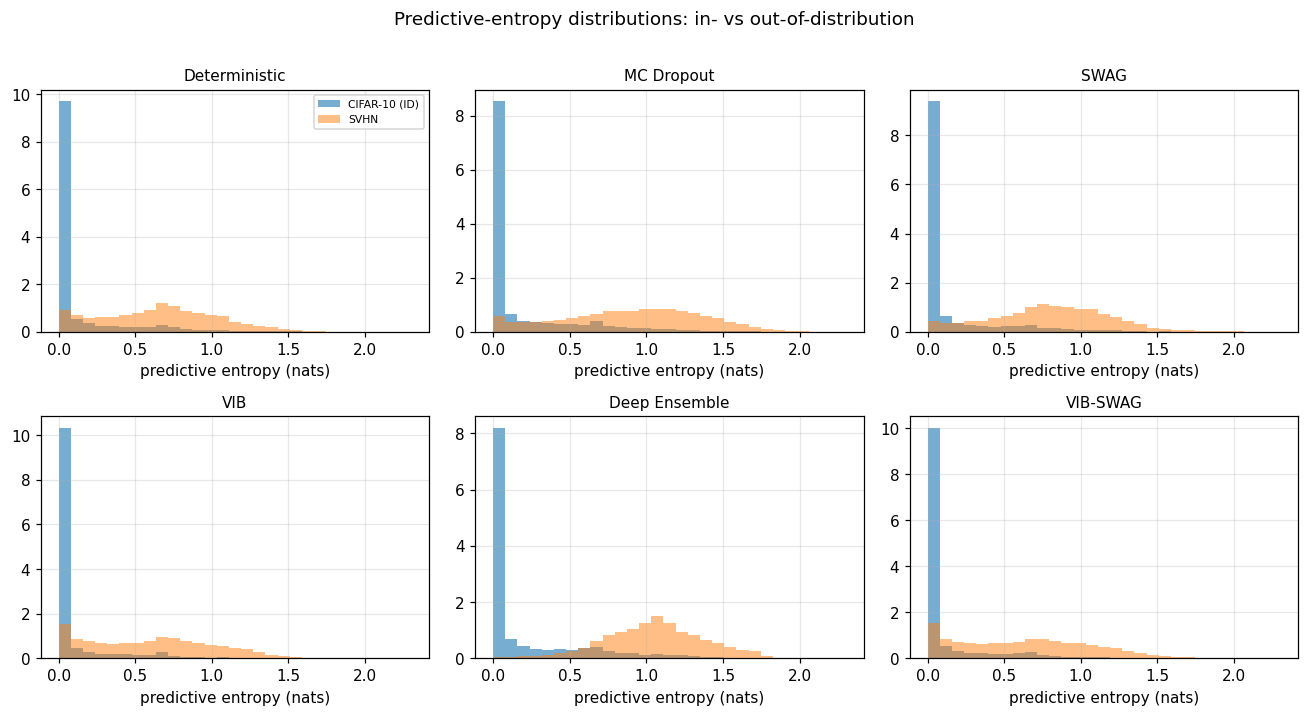

In [8]:
# Predictive-entropy distributions: ID vs each available OOD set (per model)
ncol = 3
nrow = int(np.ceil(len(MODELS) / ncol))
fig, axes = plt.subplots(nrow, ncol, figsize=(4 * ncol, 3.2 * nrow), squeeze=False)
for ax in axes.flat: ax.set_visible(False)
hmax = np.log(NUM_CLASSES)
ood_disp = {"svhn": "SVHN", "cifar10c": "CIFAR-10-C"}
for i, m in enumerate(MODELS):
    ax = axes.flat[i]; ax.set_visible(True)
    r = RESULTS[m]
    bins = np.linspace(0, hmax, 30)
    ax.hist(entropy(r["probs_test"]), bins=bins, density=True, alpha=0.6, label="CIFAR-10 (ID)")
    for split, _lbl in AVAILABLE_OOD:
        if f"probs_{split}" in r:
            ax.hist(entropy(r[f"probs_{split}"]), bins=bins, density=True, alpha=0.5,
                    label=ood_disp.get(split, split))
    ax.set_title(m, fontsize=10); ax.set_xlabel("predictive entropy (nats)")
    if i == 0: ax.legend(fontsize=7)
fig.suptitle("Predictive-entropy distributions: in- vs out-of-distribution", y=1.01, fontsize=12)
plt.tight_layout(); plt.savefig(os.path.join(FIG_DIR, "entropy_distributions.png"), bbox_inches="tight"); plt.show()


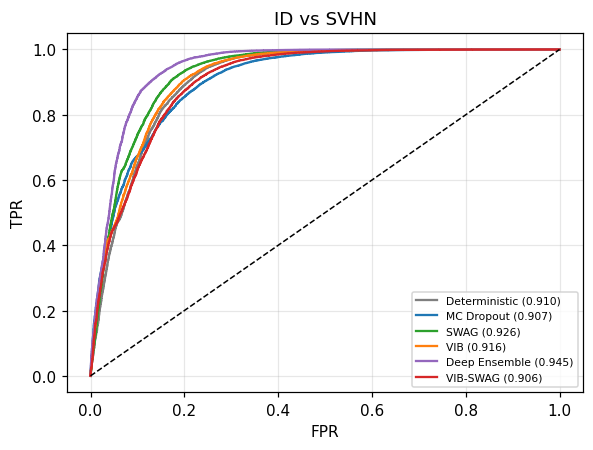

In [9]:
# ROC curves for OOD detection (one panel per available OOD set)
panels = [(f"probs_{s}", "ID vs " + ("SVHN" if s == "svhn" else "CIFAR-10-C"))
          for s, _ in AVAILABLE_OOD]
if panels:
    fig, axes = plt.subplots(1, len(panels), figsize=(5.5 * len(panels), 4.2), squeeze=False)
    for ax, (ood_key, title) in zip(axes[0], panels):
        for m in MODELS:
            r = RESULTS[m]
            if ood_key not in r:
                continue
            h_id = entropy(r["probs_test"]); h_ood = entropy(r[ood_key])
            y = np.concatenate([np.zeros(len(h_id)), np.ones(len(h_ood))])
            s = np.concatenate([h_id, h_ood])
            fpr, tpr, _ = roc_curve(y, s)
            ax.plot(fpr, tpr, color=COLOR[m], label=f"{m} ({roc_auc_score(y, s):.3f})")
        ax.plot([0, 1], [0, 1], "k--", lw=1)
        ax.set_xlabel("FPR"); ax.set_ylabel("TPR"); ax.set_title(title); ax.legend(fontsize=7)
    plt.tight_layout(); plt.savefig(os.path.join(FIG_DIR, "ood_roc.png")); plt.show()
else:
    print("No OOD splits available - skipping ROC curves.")


## 5. Selective prediction (risk–coverage)

We let each model abstain on its least-confident inputs and measure error on
the rest. Lower curves are better; **AURC** (area under the risk–coverage curve)
summarises this — a model whose confidence ranking tracks correctness well will
have low AURC even at modest accuracy.

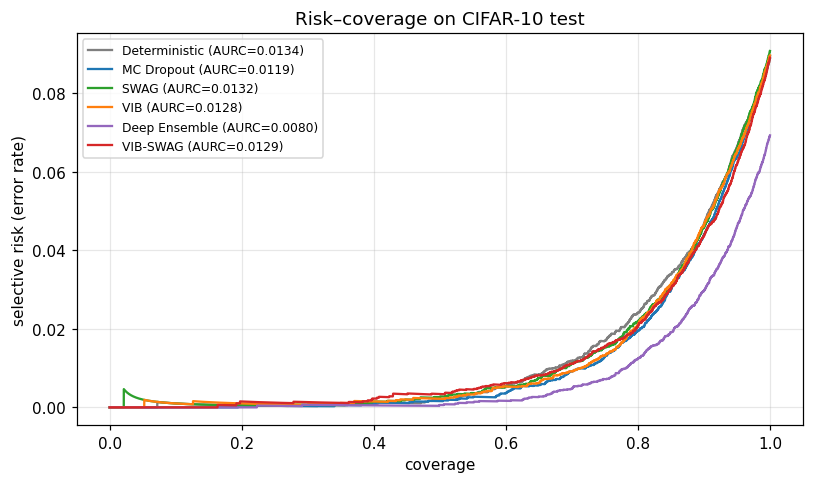

,AURC,Acc @80% coverage
Model,,
Deterministic,0.0134,0.9759
MC Dropout,0.0119,0.9805
SWAG,0.0132,0.9782
VIB,0.0128,0.9789
Deep Ensemble,0.0080,0.9876
VIB-SWAG,0.0129,0.9792


In [10]:
fig, ax = plt.subplots(figsize=(7.5, 4.5))
aurc_rows = []
for m in MODELS:
    r = RESULTS[m]
    cov, risk, aurc = risk_coverage(r["probs_test"], r["labels_test"])
    ax.plot(cov, risk, color=COLOR[m], label=f"{m} (AURC={aurc:.4f})")
    # selective accuracy at 80% coverage
    k = max(1, int(0.8 * len(cov))) - 1
    aurc_rows.append({"Model": m, "AURC": aurc, "Acc @80% coverage": 1 - risk[k]})
ax.set_xlabel("coverage"); ax.set_ylabel("selective risk (error rate)")
ax.set_title("Risk–coverage on CIFAR-10 test"); ax.legend(fontsize=8)
plt.tight_layout(); plt.savefig(os.path.join(FIG_DIR, "risk_coverage.png")); plt.show()

aurc_df = pd.DataFrame(aurc_rows).set_index("Model")
aurc_df.to_csv(os.path.join(FIG_DIR, "selective_prediction_table.csv"))
display(aurc_df.round(4))

## 6. Uncertainty decomposition

### 6a. Two-way split (every sampling model)

The standard total / aleatoric / epistemic split. For weight-space samplers
(MC Dropout, SWAG, Deep Ensemble) the epistemic term is weight disagreement.
For **VIB** the sampling axis is the *representation* bottleneck, so its
"epistemic" term is representation-level disagreement, not weight uncertainty —
labelled accordingly. The deterministic model has one sample, so its epistemic
term is ~0 by construction.

,Total H,Aleatoric,Epistemic/repr.,epi_kind
Model,,,,
Deterministic,0.1157,0.1157,0.0000,epistemic
MC Dropout,0.1791,0.1316,0.0475,epistemic
SWAG,0.1325,0.1319,0.0007,epistemic
VIB,0.0870,0.0806,0.0064,representation
Deep Ensemble,0.1981,0.1277,0.0704,epistemic
VIB-SWAG,0.1028,0.0943,0.0085,epistemic


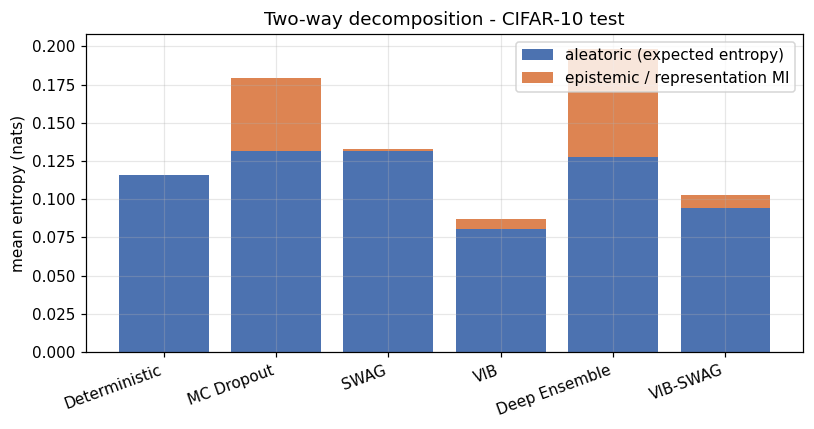

In [11]:
def two_way_for(r):
    """Return mean (total, aleatoric, epistemic) on the test set for any model,
    collapsing VIB-SWAG's (S,M,...) array to a single sample axis. Point-estimate
    models (no all_probs_test) are treated as a single sample -> zero epistemic."""
    ap = r.get("all_probs_test")
    if ap is None:
        ap = r["probs_test"][None]                      # (1, N, C)
    ap = np.asarray(ap)
    if ap.ndim == 4:
        ap = ap.reshape(-1, ap.shape[2], ap.shape[3])   # (S*M, N, C)
    d = decompose_two_way(ap)
    return d["total"].mean(), d["aleatoric"].mean(), d["epistemic"].mean()

two_rows = []
for m in MODELS:
    t, a, e = two_way_for(RESULTS[m])
    epi_label = "representation" if m == "VIB" else "epistemic"
    two_rows.append({"Model": m, "Total H": t, "Aleatoric": a,
                     "Epistemic/repr.": e, "epi_kind": epi_label})
two_df = pd.DataFrame(two_rows).set_index("Model")
display(two_df.round(4))

# stacked bar: aleatoric + epistemic = total
fig, ax = plt.subplots(figsize=(7.5, 4))
ale = two_df["Aleatoric"].values; epi = two_df["Epistemic/repr."].values
x = np.arange(len(MODELS))
ax.bar(x, ale, label="aleatoric (expected entropy)", color="#4c72b0")
ax.bar(x, epi, bottom=ale, label="epistemic / representation MI", color="#dd8452")
ax.set_xticks(x); ax.set_xticklabels(MODELS, rotation=20, ha="right")
ax.set_ylabel("mean entropy (nats)"); ax.set_title("Two-way decomposition - CIFAR-10 test")
ax.legend()
plt.tight_layout(); plt.savefig(os.path.join(FIG_DIR, "two_way_decomp.png")); plt.show()


### 6b. Three-way split (VIB-SWAG) — the central contribution

VIB-SWAG provides two mechanistically distinct stochasticity sources, giving a
weight-epistemic / bottleneck / residual split. The cells below load the
pre-computed per-input arrays (`*_test`, `*_svhn`, `*_cifar10c`) and fall back to
recomputing from the raw `(S,M,N,C)` array when needed. The first plot is the
**regime analysis** that answers the research question directly: each component's
mean across four regimes — correctly-classified ID, misclassified ID,
CIFAR-10-C corruption, and SVHN domain shift.

In [12]:
COMPONENTS = ["weight_epistemic", "bottleneck", "residual"]

def vibswag_components(r, split):
    """Per-input component arrays for split in {test, svhn, cifar10c}.
    Prefer saved arrays; fall back to recomputation from all_probs_<split>."""
    saved = {c: r.get(f"{c}_{split}") for c in COMPONENTS}
    if all(v is not None for v in saved.values()):
        return {c: np.asarray(saved[c]) for c in COMPONENTS}
    ap = r.get(f"all_probs_{split}")
    if ap is not None and np.asarray(ap).ndim == 4:
        d = decompose_three_way(ap)
        return {c: d[c] for c in COMPONENTS}
    return None   # not available (e.g. CIFAR-10-C raw not saved)

if "VIB-SWAG" in RESULTS:
    rv = RESULTS["VIB-SWAG"]
    comp_test = vibswag_components(rv, "test")
    comp_svhn = vibswag_components(rv, "svhn")
    comp_c10c = vibswag_components(rv, "cifar10c")

    # additivity check
    tot = np.asarray(rv.get("total_test"))
    if tot is None:
        tot = decompose_three_way(rv["all_probs_test"])["total"]
    summ = sum(comp_test[c] for c in COMPONENTS)
    print(f"Additivity check (test): max |sum(components) - total| = "
          f"{np.abs(summ - tot).max():.2e}  (should be ~0)")

    # Regime split on the test set: correct vs incorrect
    preds_test = rv["preds_test"]; labels_test = rv["labels_test"]
    correct = preds_test == labels_test
    candidate = {
        "ID correct":   {c: comp_test[c][correct]  for c in COMPONENTS},
        "ID incorrect": {c: comp_test[c][~correct] for c in COMPONENTS},
        "CIFAR-10-C":   comp_c10c,
        "SVHN":         comp_svhn,
    }
    # Drop regimes that are missing or empty (e.g. no misclassified ID examples)
    regimes = {}
    for k, v in candidate.items():
        if v is None: continue
        n = len(next(iter(v.values())))
        if n == 0:
            print(f"  [note] regime '{k}' has 0 examples — omitted.")
            continue
        regimes[k] = v

    reg_means = pd.DataFrame(
        {reg: {**{c: float(np.mean(vals[c])) for c in COMPONENTS},
               "n": int(len(next(iter(vals.values()))))}
         for reg, vals in regimes.items()}).T
    reg_means["n"] = reg_means["n"].astype(int)
    reg_means.to_csv(os.path.join(FIG_DIR, "vibswag_regime_means.csv"))
    display(reg_means.round(4))
else:
    print("VIB-SWAG results not loaded — skipping three-way decomposition.")

Additivity check (test): max |sum(components) - total| = 2.29e-06  (should be ~0)


,weight_epistemic,bottleneck,residual,n
ID correct,0.0011,0.0040,0.0563,9109
ID incorrect,0.0092,0.0331,0.4832,891
SVHN,0.0091,0.0342,0.5870,26032


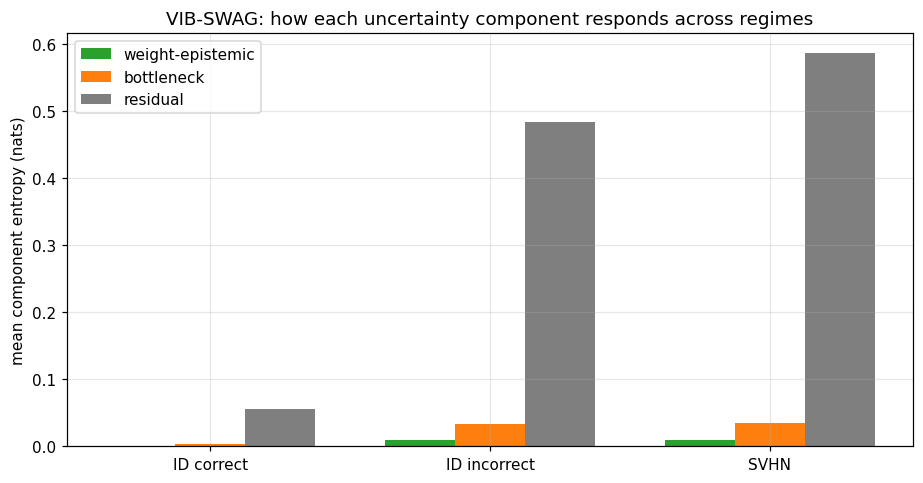

In [13]:
if "VIB-SWAG" in RESULTS:
    comp_colors = {"weight_epistemic": "#2ca02c", "bottleneck": "#ff7f0e", "residual": "#7f7f7f"}
    regs = list(regimes.keys())
    x = np.arange(len(regs)); w = 0.25
    fig, ax = plt.subplots(figsize=(8.5, 4.5))
    for j, c in enumerate(COMPONENTS):
        vals = [np.mean(regimes[reg][c]) for reg in regs]
        ax.bar(x + (j - 1) * w, vals, w, label=c.replace("_", "-"), color=comp_colors[c])
    ax.set_xticks(x); ax.set_xticklabels(regs)
    ax.set_ylabel("mean component entropy (nats)")
    ax.set_title("VIB-SWAG: how each uncertainty component responds across regimes")
    ax.legend()
    plt.tight_layout(); plt.savefig(os.path.join(FIG_DIR, "vibswag_regime_bars.png")); plt.show()

### 6c. Which component detects which shift?

The sharpest test of the research question: use **each component on its own** as
an OOD score and measure how well it separates ID from each shift. If the
mechanisms are genuinely distinct, the components should specialise — e.g.
weight-epistemic responding most to domain shift (SVHN) while the bottleneck
term responds to in-distribution ambiguity (CIFAR-10-C). Equal columns would
instead suggest the two sources are redundant.

,weight_epistemic,bottleneck,residual,total
SVHN,0.8828,0.8822,0.9079,0.9061


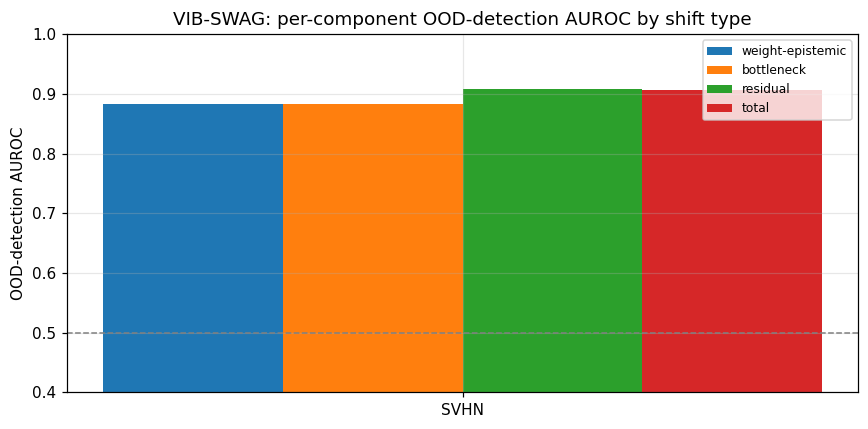

In [14]:
if "VIB-SWAG" in RESULTS:
    comp_auroc = {}
    for split, label in [("svhn", "SVHN"), ("cifar10c", "CIFAR-10-C")]:
        ood = vibswag_components(rv, split)
        if ood is None:
            continue
        row = {}
        for c in COMPONENTS:
            row[c] = ood_scores(comp_test[c], ood[c])["auroc"]
        # plus total entropy as reference
        row["total"] = ood_scores(np.asarray(rv.get("total_test")), np.asarray(rv.get(f"total_{split}")))["auroc"]
        comp_auroc[label] = row
    comp_auroc_df = pd.DataFrame(comp_auroc).T
    comp_auroc_df.to_csv(os.path.join(FIG_DIR, "vibswag_component_auroc.csv"))
    display(comp_auroc_df.round(4))

    fig, ax = plt.subplots(figsize=(8, 4))
    cols = list(comp_auroc_df.columns)
    x = np.arange(len(comp_auroc_df.index)); w = 0.8 / len(cols)
    for j, c in enumerate(cols):
        ax.bar(x + (j - (len(cols)-1)/2) * w, comp_auroc_df[c].values, w, label=c.replace("_", "-"))
    ax.axhline(0.5, color="grey", ls="--", lw=1)
    ax.set_xticks(x); ax.set_xticklabels(comp_auroc_df.index)
    ax.set_ylabel("OOD-detection AUROC"); ax.set_ylim(0.4, 1.0)
    ax.set_title("VIB-SWAG: per-component OOD-detection AUROC by shift type")
    ax.legend(fontsize=8)
    plt.tight_layout(); plt.savefig(os.path.join(FIG_DIR, "vibswag_component_auroc.png")); plt.show()

### 6d. Does combining help? VIB-SWAG vs its ablations

The other half of the research question: does the combination beat VIB alone and
SWAG alone on calibration and OOD detection? This compares the three directly on
ECE, OOD AUROC (both shifts) and AURC.

,ECE,AURC,AUROC SVHN
Model,,,
VIB,0.0567,0.0128,0.9161
SWAG,0.0414,0.0132,0.9264
VIB-SWAG,0.0504,0.0129,0.9061


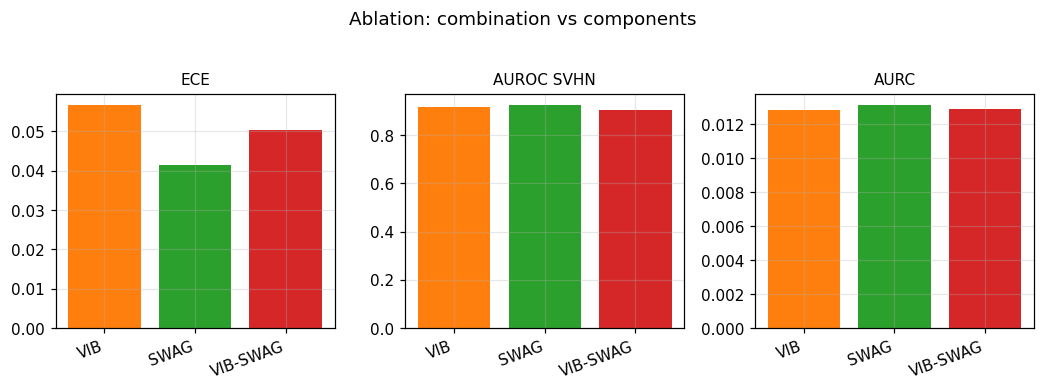

In [15]:
ablation_set = [m for m in ["VIB", "SWAG", "VIB-SWAG"] if m in RESULTS]
if len(ablation_set) >= 2:
    abl = []
    for m in ablation_set:
        r = RESULTS[m]
        ece, _ = expected_calibration_error(r["probs_test"], r["labels_test"])
        h_id = entropy(r["probs_test"])
        _, _, aurc = risk_coverage(r["probs_test"], r["labels_test"])
        row = {"Model": m, "ECE": ece, "AURC": aurc}
        if "probs_svhn" in r:
            row["AUROC SVHN"]   = ood_scores(h_id, entropy(r["probs_svhn"]))["auroc"]
        if "probs_cifar10c" in r:
            row["AUROC C-10-C"] = ood_scores(h_id, entropy(r["probs_cifar10c"]))["auroc"]
        abl.append(row)
    abl_df = pd.DataFrame(abl).set_index("Model")
    abl_df.to_csv(os.path.join(FIG_DIR, "ablation_table.csv"))
    display(abl_df.round(4))

    metrics = [me for me in ["ECE", "AUROC SVHN", "AUROC C-10-C", "AURC"]
               if me in abl_df.columns]
    fig, axes = plt.subplots(1, len(metrics), figsize=(3.2 * len(metrics), 3.4), squeeze=False)
    for ax, met in zip(axes[0], metrics):
        ax.bar(range(len(ablation_set)), abl_df[met].values,
               color=[COLOR[m] for m in ablation_set])
        ax.set_xticks(range(len(ablation_set)))
        ax.set_xticklabels(ablation_set, rotation=20, ha="right")
        ax.set_title(met, fontsize=10)
    fig.suptitle("Ablation: combination vs components", y=1.03)
    plt.tight_layout(); plt.savefig(os.path.join(FIG_DIR, "ablation.png"), bbox_inches="tight"); plt.show()
else:
    print("Need at least two of {VIB, SWAG, VIB-SWAG} loaded for the ablation.")


## 7. Consolidated summary

A single master table joining the headline metrics, exported to CSV/JSON, plus
an auto-generated readout of the key comparisons. The narrative is templated
from the computed numbers — read it as a starting point for the thesis write-up,
not a substitute for interpretation.

In [16]:
master = perf_df.join(ood_df, how="left").join(aurc_df, how="left")
master.to_csv(os.path.join(FIG_DIR, "master_results.csv"))
with open(os.path.join(FIG_DIR, "master_results.json"), "w") as fh:
    json.dump(master.round(5).to_dict(orient="index"), fh, indent=2)
display(master.round(4))

,Acc (clean),NLL,Brier,ECE,AUROC SVHN,AUPR SVHN,AURC,Acc @80% coverage
Model,,,,,,,,
Deterministic,0.9111,0.3406,0.1402,0.0449,0.9097,0.9470,0.0134,0.9759
MC Dropout,0.9105,0.2752,0.1290,0.0218,0.9071,0.9523,0.0119,0.9805
SWAG,0.9092,0.3171,0.1382,0.0414,0.9264,0.9566,0.0132,0.9782
VIB,0.9103,0.3975,0.1452,0.0567,0.9161,0.9530,0.0128,0.9789
Deep Ensemble,0.9307,0.2091,0.1029,0.0084,0.9447,0.9675,0.0080,0.9876
VIB-SWAG,0.9109,0.3516,0.1383,0.0504,0.9061,0.9479,0.0129,0.9792


In [17]:
def best(col, lower_is_better):
    if col not in master.columns:
        return ("-", float("nan"))
    s = master[col].dropna()
    if s.empty: return ("-", float("nan"))
    m = s.idxmin() if lower_is_better else s.idxmax()
    return (m, s[m])

lines = ["KEY FINDINGS (auto-generated from the loaded results)", "=" * 56]
b, v = best("Acc (clean)", False);   lines.append(f"- Highest clean accuracy : {b} ({v:.4f})")
b, v = best("ECE", True);            lines.append(f"- Best calibration (ECE) : {b} ({v:.4f})")
b, v = best("NLL", True);            lines.append(f"- Best NLL               : {b} ({v:.4f})")
b, v = best("AUROC SVHN", False);    lines.append(f"- Best SVHN OOD AUROC    : {b} ({v:.4f})")
b, v = best("AUROC C-10-C", False);  lines.append(f"- Best CIFAR-10-C AUROC  : {b} ({v:.4f})")
b, v = best("AURC", True);           lines.append(f"- Best selective AURC    : {b} ({v:.4f})")

if "VIB-SWAG" in RESULTS and "comp_auroc_df" in globals() and not comp_auroc_df.empty:
    lines += ["", "Three-way decomposition - which component leads per shift:"]
    for shift in comp_auroc_df.index:
        row = comp_auroc_df.loc[shift, COMPONENTS] if all(c in comp_auroc_df.columns for c in COMPONENTS) else comp_auroc_df.loc[shift]
        lead = row.idxmax()
        lines.append(f"  - {shift:<12}: {lead.replace('_','-')} (AUROC {row.max():.3f})")

if {"VIB", "SWAG", "VIB-SWAG"}.issubset(RESULTS):
    lines += ["", "Ablation (does combining help?):"]
    for met, lo in [("ECE", True), ("AUROC SVHN", False), ("AUROC C-10-C", False), ("AURC", True)]:
        if met not in master.columns:
            continue
        sub = master.loc[["VIB", "SWAG", "VIB-SWAG"], met].dropna()
        if sub.empty:
            continue
        win = sub.idxmin() if lo else sub.idxmax()
        tag = "[v] combination wins" if win == "VIB-SWAG" else f"[x] {win} leads"
        lines.append(f"  - {met:<13}: {tag}")

print("\n".join(lines))


KEY FINDINGS (auto-generated from the loaded results)
- Highest clean accuracy : Deep Ensemble (0.9307)
- Best calibration (ECE) : Deep Ensemble (0.0084)
- Best NLL               : Deep Ensemble (0.2091)
- Best SVHN OOD AUROC    : Deep Ensemble (0.9447)
- Best CIFAR-10-C AUROC  : - (nan)
- Best selective AURC    : Deep Ensemble (0.0080)

Three-way decomposition - which component leads per shift:
  - SVHN        : residual (AUROC 0.908)

Ablation (does combining help?):
  - ECE          : [x] SWAG leads
  - AUROC SVHN   : [x] SWAG leads
  - AURC         : [x] VIB leads
